In [112]:
cd ~/code/StinoNL/transfer_carrousel

/home/stijn/code/StinoNL/transfer_carrousel


/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [113]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.linear_model import LinearRegression
import seaborn as sns
import numpy as np


# Load the dataset
df_first_dataset = pd.read_csv("first_dataset/j_first_attempt.csv")

# Show first rows
df_first_dataset.head()

,player_id,player_name,club_id,club_name,age,position,market_value_in_eur,minutes_played,goals,assists
0,3333,James Milner,1237,Brighton And Hove Albion Football Club,39.0,Midfield,1000000.0,172,0,0
1,5336,Anastasios Tsokanis,60949,Volou Neos Podosferikos Syllogos,34.0,Midfield,300000.0,923,0,0
2,7161,Jonas Hofmann,15,Bayer 04 Leverkusen Fußball,33.0,Midfield,3000000.0,545,2,2
3,7825,Pepe Reina,1047,Calcio Como,43.0,Goalkeeper,600000.0,990,0,0
4,11530,Lionel Carole,3205,Kayserispor Kulübü,34.0,Defender,400000.0,1798,0,0


In [114]:
#checking the shape of the dataset
df_first_dataset.shape

(6400, 10)

In [115]:
# checking missing values
missing = df_first_dataset.isna().sum().sort_values(ascending=False)
print("Missing values:\n", missing[missing > 0])

Missing values:
 age                    337
position               337
market_value_in_eur    337
club_name              101
dtype: int64


In [116]:
# dropping row
# s missing essential information
df_first_dataset = df_first_dataset.dropna(subset=["age", "position", "market_value_in_eur"])

In [117]:
# drop rows with Na position
df_first_dataset= df_first_dataset[~df_first_dataset['position'].isna()]
df_first_dataset= df_first_dataset[df_first_dataset['position'] != 'nan']
df_first_dataset.head(3)

,player_id,player_name,club_id,club_name,age,position,market_value_in_eur,minutes_played,goals,assists
0,3333,James Milner,1237,Brighton And Hove Albion Football Club,39.0,Midfield,1000000.0,172,0,0
1,5336,Anastasios Tsokanis,60949,Volou Neos Podosferikos Syllogos,34.0,Midfield,300000.0,923,0,0
2,7161,Jonas Hofmann,15,Bayer 04 Leverkusen Fußball,33.0,Midfield,3000000.0,545,2,2


In [118]:
print(df_first_dataset['position'].unique())

['Midfield' 'Goalkeeper' 'Defender' 'Attack' 'Missing']


In [119]:
# remove missing
df_first_dataset = df_first_dataset[df_first_dataset['position'] != 'Missing']

In [120]:
print(df_first_dataset['position'].unique())

['Midfield' 'Goalkeeper' 'Defender' 'Attack']


In [121]:
#checking the shape of the dataset
df_first_dataset.shape

(6062, 10)

In [122]:
# creating new feature goals and assists per minute for model and player efficiency
df_first_dataset["goals_per_minute"] = df_first_dataset["goals"] / df_first_dataset["minutes_played"].replace(0, np.nan)
df_first_dataset["assists_per_minute"] = df_first_dataset["assists"] / df_first_dataset["minutes_played"].replace(0, np.nan)

# if there are infinite values
df_first_dataset["goals_per_minute"] = df_first_dataset["goals_per_minute"].fillna(0)
df_first_dataset["assists_per_minute"] = df_first_dataset["assists_per_minute"].fillna(0)
df_first_dataset.head(5)


,player_id,player_name,club_id,club_name,age,position,market_value_in_eur,minutes_played,goals,assists,goals_per_minute,assists_per_minute
0,3333,James Milner,1237,Brighton And Hove Albion Football Club,39.0,Midfield,1000000.0,172,0,0,0.00000,0.00000
1,5336,Anastasios Tsokanis,60949,Volou Neos Podosferikos Syllogos,34.0,Midfield,300000.0,923,0,0,0.00000,0.00000
2,7161,Jonas Hofmann,15,Bayer 04 Leverkusen Fußball,33.0,Midfield,3000000.0,545,2,2,0.00367,0.00367
3,7825,Pepe Reina,1047,Calcio Como,43.0,Goalkeeper,600000.0,990,0,0,0.00000,0.00000
4,11530,Lionel Carole,3205,Kayserispor Kulübü,34.0,Defender,400000.0,1798,0,0,0.00000,0.00000


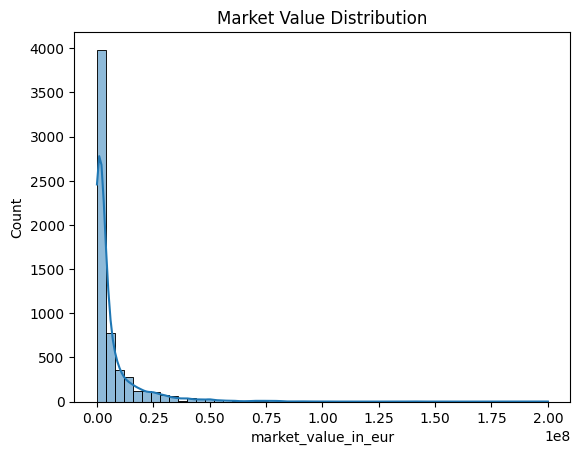

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_first_dataset["market_value_in_eur"], bins=50, kde=True)
plt.title("Market Value Distribution")
plt.show()


In [ ]:
# Drop non-feature columns from X
X = df_first_dataset.drop(columns=[
    'market_value_in_eur',
    'player_id',
    'player_name',
    'club_id',
    'club_name'
])

# based on the above graph it is very skews and in the regression lecture we can apply a log transform to stabalize variance and improve performance
y =df_first_dataset["market_value_in_eur"]


In [125]:
#robust scale the numerical features,minutes played can be allot or a little goals are less than 50 and variety of ages some players like mbappe will have massive transfer values vs others
# positions have impacts on the valuations so I decided to one hot encode those
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = ['age', 'minutes_played', 'goals', 'assists', 'goals_per_minute', 'assists_per_minute']
cat_cols = ['position']

# Robust pipeline for numerical columns
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

#onehotencode for position
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine both in a column transformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])


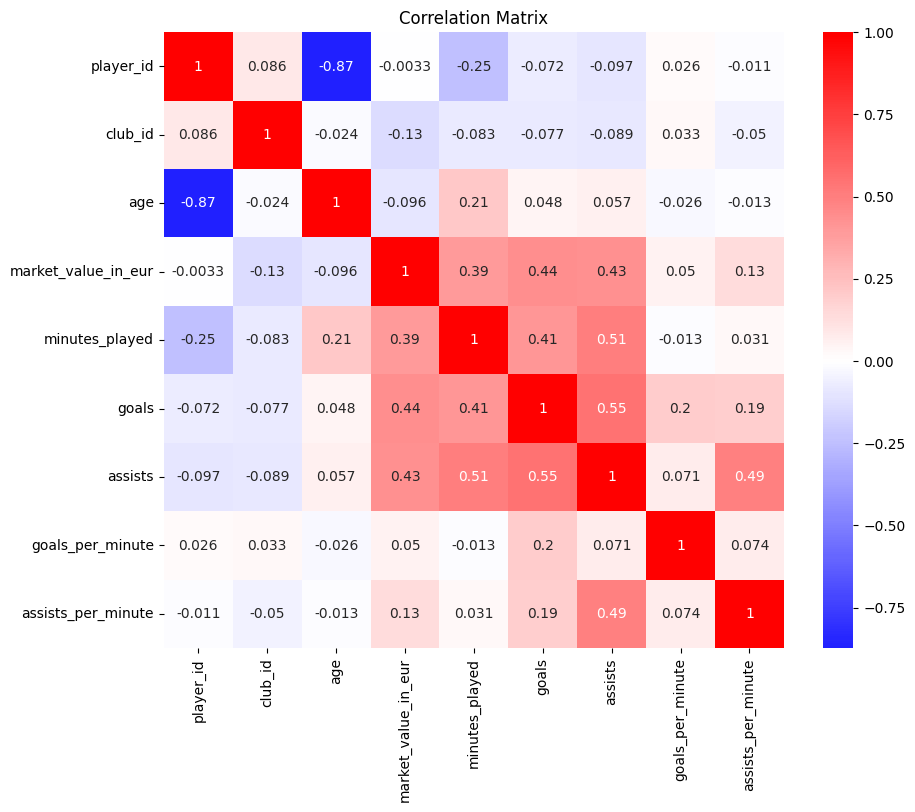

,feature_1,feature_2,correlation,absolute_correlation
2,player_id,age,-0.873335,0.873335
18,age,player_id,-0.873335,0.873335
51,goals,assists,0.550739,0.550739
59,assists,goals,0.550739,0.550739
42,minutes_played,assists,0.505441,0.505441
58,assists,minutes_played,0.505441,0.505441
62,assists,assists_per_minute,0.491440,0.491440
78,assists_per_minute,assists,0.491440,0.491440
48,goals,market_value_in_eur,0.443147,0.443147
32,market_value_in_eur,goals,0.443147,0.443147


In [126]:
import matplotlib.pyplot as plt

# Pearson correlation matrix
correlation_matrix = df_first_dataset.select_dtypes(include='number').corr()

# Heatmap (optional for visualization)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='bwr', center=0)
plt.title("Correlation Matrix")
plt.show()

# flatten like in the lecture
corr_df = correlation_matrix.stack().reset_index()
corr_df.columns = ['feature_1', 'feature_2', 'correlation']

# Remove self-correlations
corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2']]

# Add absolute correlation
corr_df['absolute_correlation'] = np.abs(corr_df['correlation'])

# Sort and show top 10
top_corr = corr_df.sort_values(by='absolute_correlation', ascending=False).head(10)
display(top_corr)

In [127]:
#creating a basedline model

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# the model
model = LinearRegression()

# wrapping the preprocessing
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Evaluate with R² using cross-validation
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print("R2 scores:", scores)
print("Mean R2:", scores.mean())


R2 scores: [-0.34955567  0.29910162  0.29128124  0.3256087   0.08566411]
Mean R2: 0.13041999832695247


In [ ]:
# ridge from the lecture:
# "“Ridge is a good choice when all features are useful but noisy. It improves generalization by discouraging large weights.”
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_params = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ridge_model)
])

# use the gridsearch to find best alpha
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X, y)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best Ridge R²:", ridge_grid.best_score_)


Best Ridge alpha: {'model__alpha': 100.0}
Best Ridge R²: 0.13176023396044378


In [ ]:
# lasso from the lecture:
# "Regularization improves generalization by penalizing complex models (Ridge and Lasso help avoid overfitting).
# Lasso also performs automatic feature selection by shrinking some coefficients to zero"
from sklearn.linear_model import Lasso

lasso_model = Lasso(max_iter=10_000)  # prevent convergence warnings
lasso_params = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lasso_model)
])

lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X, y)

print("Best Lasso alpha:", lasso_grid.best_params_)
print("Best Lasso R²:", lasso_grid.best_score_)


Best Lasso alpha: {'model__alpha': 0.0001}
Best Lasso R²: 0.13041999832523501


In [130]:
#trying a random forest
# notes from lecture "Random forests are robust to outliers and handle both numerical and categorical data well."
# They perform automatic feature selection by reducing the importance of irrelevant features.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Create the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Wrap the model in the preprocessing pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# Evaluate using R² with cross-validation
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')
print("Random Forest R2 scores:", rf_scores)
print("Mean Random Forest R2:", rf_scores.mean())


Random Forest R2 scores: [-0.79551276  0.42759291  0.33006346  0.26504264  0.01418416]
Mean Random Forest R2: 0.04827408325168518
